<a href="https://colab.research.google.com/github/thezaarazone/My-Anatomy/blob/main/covid19_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 20)

print("Ready.")

Ready.


In [2]:
cases = pd.read_csv(
    "https://raw.githubusercontent.com/imdevskp/covid-19-india-data/master/complete.csv"
)
vax = pd.read_csv(
    "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/vaccinations/country_data/India.csv"
)

print("Cases shape:", cases.shape)
print("Vaccination shape:", vax.shape)
cases.head()

Cases shape: (4692, 10)
Vaccination shape: (1250, 8)


,Date,Name of State / UT,Latitude,Longitude,Total Confirmed cases,Death,Cured/Discharged/Migrated,New cases,New deaths,New recovered
0,2020-01-30,Kerala,10.8505,76.2711,1.0,0,0.0,0,0,0
1,2020-01-31,Kerala,10.8505,76.2711,1.0,0,0.0,0,0,0
2,2020-02-01,Kerala,10.8505,76.2711,2.0,0,0.0,1,0,0
3,2020-02-02,Kerala,10.8505,76.2711,3.0,0,0.0,1,0,0
4,2020-02-03,Kerala,10.8505,76.2711,3.0,0,0.0,0,0,0


In [3]:
cases.dtypes

,0
Date,object
Name of State / UT,object
Latitude,float64
Longitude,float64
Total Confirmed cases,float64
Death,object
Cured/Discharged/Migrated,float64
New cases,int64
New deaths,int64
New recovered,int64


In [4]:

cases.isna().sum()

,0
Date,0
Name of State / UT,0
Latitude,0
Longitude,0
Total Confirmed cases,0
Death,0
Cured/Discharged/Migrated,0
New cases,0
New deaths,0
New recovered,0


In [5]:
print("Number of unique state/UT names:", cases["Name of State / UT"].nunique())
sorted(cases["Name of State / UT"].unique())

Number of unique state/UT names: 40


['Andaman and Nicobar Islands',
 'Andhra Pradesh',
 'Arunachal Pradesh',
 'Assam',
 'Bihar',
 'Chandigarh',
 'Chhattisgarh',
 'Dadra and Nagar Haveli and Daman and Diu',
 'Delhi',
 'Goa',
 'Gujarat',
 'Haryana',
 'Himachal Pradesh',
 'Jammu and Kashmir',
 'Jharkhand',
 'Karnataka',
 'Kerala',
 'Ladakh',
 'Madhya Pradesh',
 'Maharashtra',
 'Manipur',
 'Meghalaya',
 'Mizoram',
 'Nagaland',
 'Odisha',
 'Puducherry',
 'Punjab',
 'Rajasthan',
 'Sikkim',
 'Tamil Nadu',
 'Telangana',
 'Telangana***',
 'Telengana',
 'Tripura',
 'Union Territory of Chandigarh',
 'Union Territory of Jammu and Kashmir',
 'Union Territory of Ladakh',
 'Uttar Pradesh',
 'Uttarakhand',
 'West Bengal']

In [6]:
# Rename to clean, snake_case column names
cases.columns = [
    "date", "state", "lat", "long", "confirmed",
    "deaths", "cured", "new_cases", "new_deaths", "new_recovered",
]

# Fix data types
cases["date"] = pd.to_datetime(cases["date"])
cases["deaths"] = pd.to_numeric(cases["deaths"], errors="coerce").fillna(0).astype(int)
cases["confirmed"] = cases["confirmed"].astype(int)
cases["cured"] = cases["cured"].astype(int)

# Fix inconsistent state names
name_fix = {
    "Telangana***": "Telangana",
    "Telengana": "Telangana",
    "Union Territory of Jammu and Kashmir": "Jammu and Kashmir",
    "Union Territory of Ladakh": "Ladakh",
    "Union Territory of Chandigarh": "Chandigarh",
}
cases["state"] = cases["state"].replace(name_fix)

# Drop any exact duplicate (date, state) rows this merge might create
cases = cases.drop_duplicates(subset=["date", "state"]).sort_values(["state", "date"]).reset_index(drop=True)

# A derived column: active cases = confirmed - deaths - recovered
cases["active"] = cases["confirmed"] - cases["deaths"] - cases["cured"]

print("Clean state count:", cases["state"].nunique())
cases.dtypes

Clean state count: 35


,0
date,datetime64[ns]
state,object
lat,float64
long,float64
confirmed,int64
deaths,int64
cured,int64
new_cases,int64
new_deaths,int64
new_recovered,int64


In [7]:

national = cases.groupby("date", as_index=False)[["confirmed", "deaths", "cured"]].sum()
national["recovery_rate"] = (national["cured"] / national["confirmed"] * 100).round(2)
national["death_rate"] = (national["deaths"] / national["confirmed"] * 100).round(2)
national["new_confirmed"] = national["confirmed"].diff().fillna(national["confirmed"])

national.tail()

,date,confirmed,deaths,cured,recovery_rate,death_rate,new_confirmed
181,2020-08-02,1750723,37364,1145629,65.44,2.13,54735.0
182,2020-08-03,1803695,38135,1186203,65.77,2.11,52972.0
183,2020-08-04,1855745,38938,1230509,66.31,2.10,52050.0
184,2020-08-05,1908254,39795,1282215,67.19,2.09,52509.0
185,2020-08-06,1964536,40699,1328336,67.62,2.07,56282.0


In [8]:

latest_date = cases["date"].max()
latest_row = national.iloc[-1]

print(f"As of {latest_date.date()}:")
print(f"  Total confirmed : {latest_row['confirmed']:,}")
print(f"  Total recovered : {latest_row['cured']:,}")
print(f"  Total deaths    : {latest_row['deaths']:,}")
print(f"  Recovery rate   : {latest_row['recovery_rate']}%")
print(f"  Death rate      : {latest_row['death_rate']}%")


As of 2020-08-06:
  Total confirmed : 1,964,536
  Total recovered : 1,328,336
  Total deaths    : 40,699
  Recovery rate   : 67.62%
  Death rate      : 2.07%


In [9]:
latest = cases[cases["date"] == latest_date].copy()
latest["recovery_rate"] = (latest["cured"] / latest["confirmed"] * 100).round(2)
latest["death_rate"] = (latest["deaths"] / latest["confirmed"] * 100).round(2)
latest = latest.sort_values("confirmed", ascending=False).reset_index(drop=True)

top10 = latest.head(10)
top10[["state", "confirmed", "deaths", "cured", "recovery_rate", "death_rate"]]

,state,confirmed,deaths,cured,recovery_rate,death_rate
0,Maharashtra,468265,16476,305521,65.25,3.52
1,Tamil Nadu,273460,4461,214815,78.55,1.63
2,Andhra Pradesh,186461,1681,104354,55.97,0.90
3,Karnataka,151449,2804,74679,49.31,1.85
4,Delhi,140232,4044,126116,89.93,2.88
5,Uttar Pradesh,104388,1857,60558,58.01,1.78
6,West Bengal,83800,1846,58962,70.36,2.20
7,Telangana,73050,589,52103,71.33,0.81
8,Gujarat,66669,2556,49433,74.15,3.83
9,Bihar,64770,355,42414,65.48,0.55


In [13]:

cases["month"] = cases["date"].dt.strftime("%Y-%m")
month_pivot = cases[cases["state"].isin(top10["state"].head(5))].pivot_table(
    values="new_cases", index="state", columns="month", aggfunc="sum", fill_value=0
)
month_pivot

month,2020-03,2020-04,2020-05,2020-06,2020-07,2020-08
state,,,,,,
Andhra Pradesh,39,1292,2237,10322,116666,55904
Delhi,96,3342,15110,66612,49242,5829
Karnataka,82,452,2387,11373,104337,32817
Maharashtra,218,9699,55253,104715,241915,56467
Tamil Nadu,73,2088,19022,65040,153754,33482


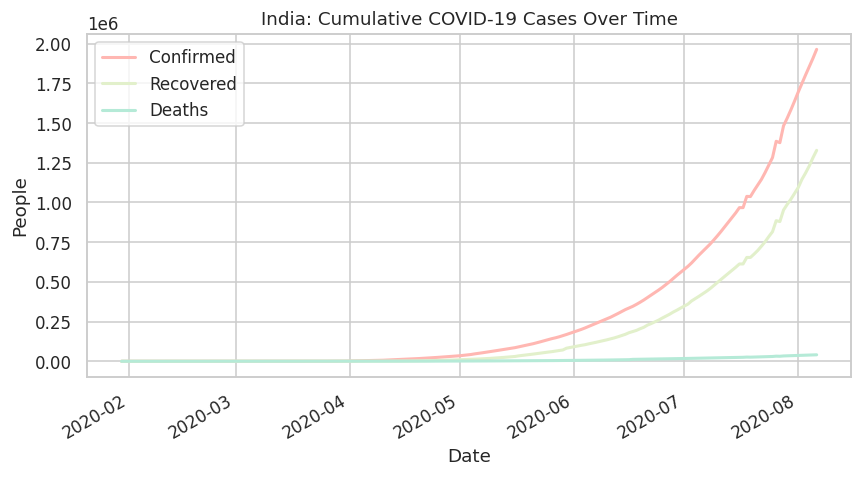

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(national["date"], national["confirmed"], label="Confirmed", color="#FFB7B2", lw=2)
ax.plot(national["date"], national["cured"], label="Recovered", color="#E2F0CB", lw=2)
ax.plot(national["date"], national["deaths"], label="Deaths", color="#B5EAD7", lw=2)
ax.set_title("India: Cumulative COVID-19 Cases Over Time")
ax.set_xlabel("Date"); ax.set_ylabel("People")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

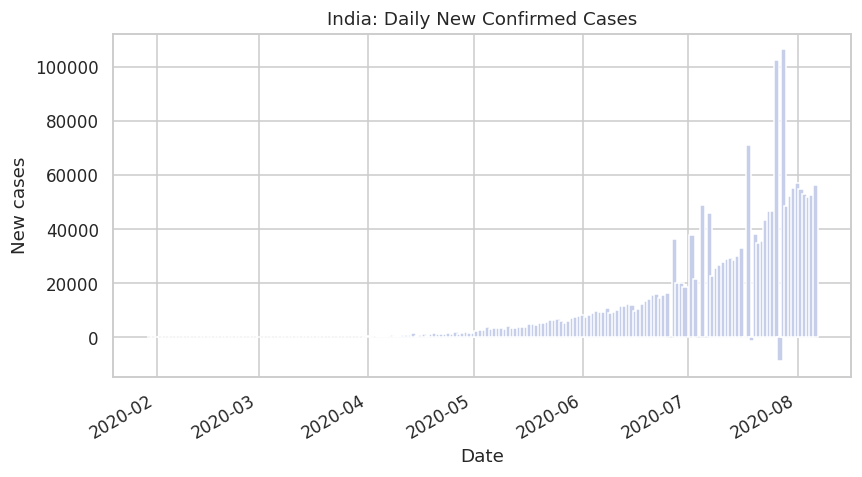

In [15]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(national["date"], national["new_confirmed"], color="#C7CEEA", width=1.5)
ax.set_title("India: Daily New Confirmed Cases")
ax.set_xlabel("Date"); ax.set_ylabel("New cases")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [17]:
v = [
    "#FFB7B2", "#FFDAC1", "#E2F0CB", "#B5EAD7", "#C7CEEA",
    "#FFC6FF", "#BDB2FF", "#CAFFBF", "#FDFFB6", "#FFADAD"
]

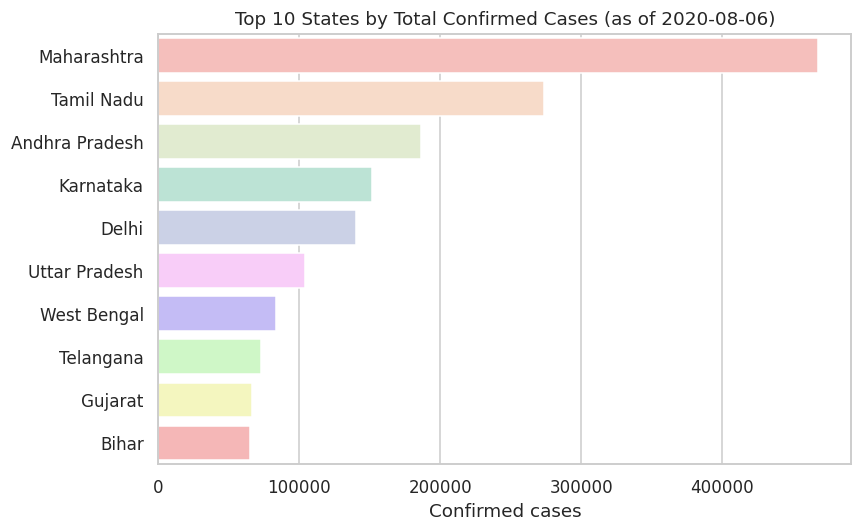

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=top10, y="state", x="confirmed", hue="state", palette=v, legend=False, ax=ax)

ax.set_title(f"Top 10 States by Total Confirmed Cases (as of {latest_date.date()})")
ax.set_xlabel("Confirmed cases")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

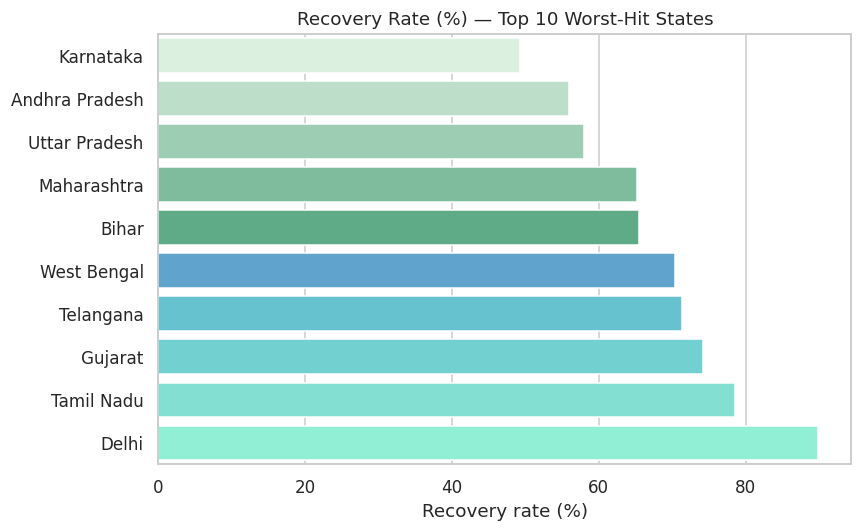

In [19]:
v_recovery = [
    "#D8F3DC", "#B7E4C7", "#95D5B2", "#74C69D", "#52B788",
    "#4EA8DE", "#56CFE1", "#64DFDF", "#72EFDD", "#80FFDB"
]

top10_sorted = top10.sort_values("recovery_rate")
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=top10_sorted, y="state", x="recovery_rate", hue="state", palette=v_recovery, legend=False, ax=ax)

ax.set_title("Recovery Rate (%) — Top 10 Worst-Hit States")
ax.set_xlabel("Recovery rate (%)")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

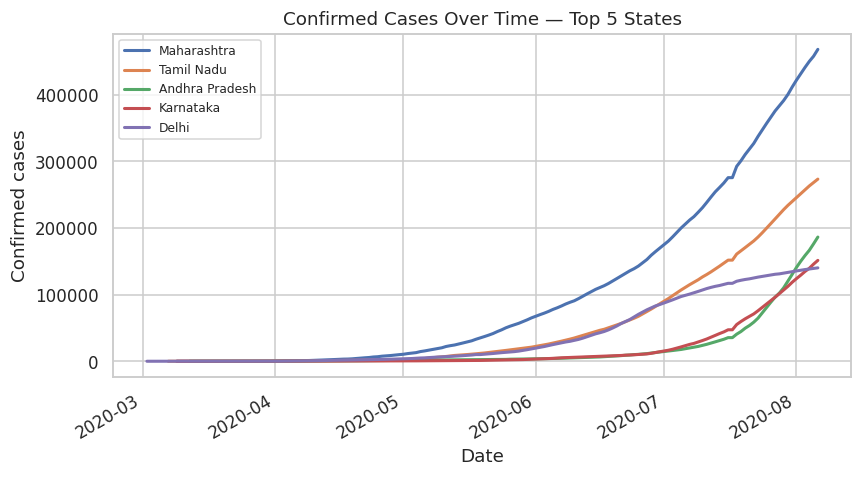

In [20]:
top5_states = top10["state"].head(5).tolist()

fig, ax = plt.subplots(figsize=(8, 4.5))
for s in top5_states:
    sub = cases[cases["state"] == s]
    ax.plot(sub["date"], sub["confirmed"], label=s, lw=2)
ax.set_title("Confirmed Cases Over Time — Top 5 States")
ax.set_xlabel("Date"); ax.set_ylabel("Confirmed cases")
ax.legend(fontsize=8)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

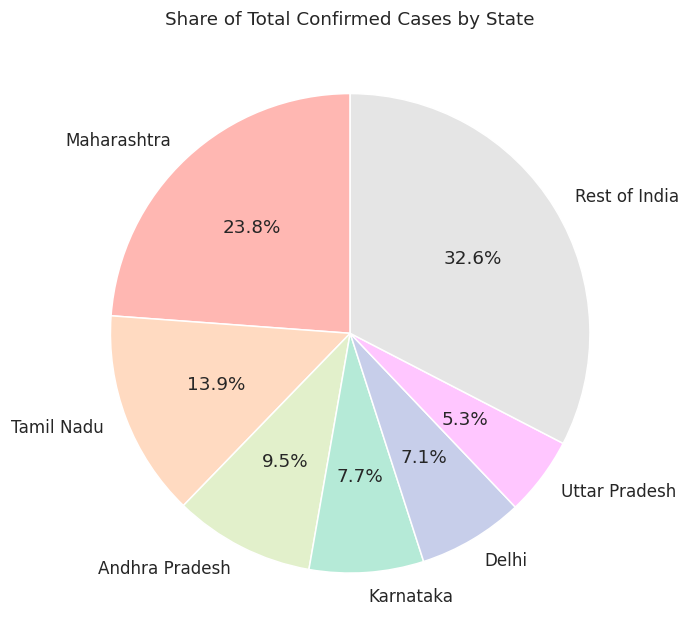

In [21]:
v_pie = ["#FFB7B2", "#FFDAC1", "#E2F0CB", "#B5EAD7", "#C7CEEA", "#FFC6FF", "#E5E5E5"]

top6 = latest.nlargest(6, "confirmed")[["state", "confirmed"]]
others = latest["confirmed"].sum() - top6["confirmed"].sum()
pie_labels = top6["state"].tolist() + ["Rest of India"]
pie_values = top6["confirmed"].tolist() + [others]

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.pie(pie_values, labels=pie_labels, autopct="%1.1f%%", startangle=90, colors=v_pie)

ax.set_title("Share of Total Confirmed Cases by State")
plt.tight_layout()
plt.show()

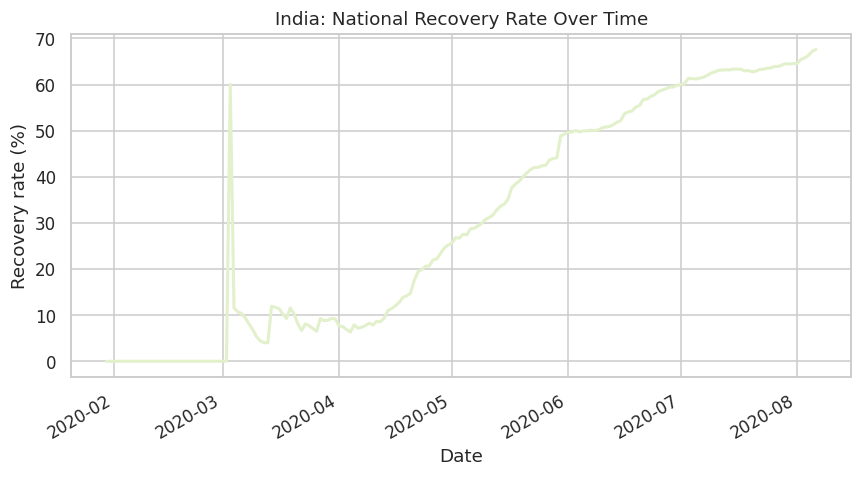

In [22]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(national["date"], national["recovery_rate"], color="#E2F0CB", lw=2)
ax.set_title("India: National Recovery Rate Over Time")
ax.set_xlabel("Date"); ax.set_ylabel("Recovery rate (%)")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

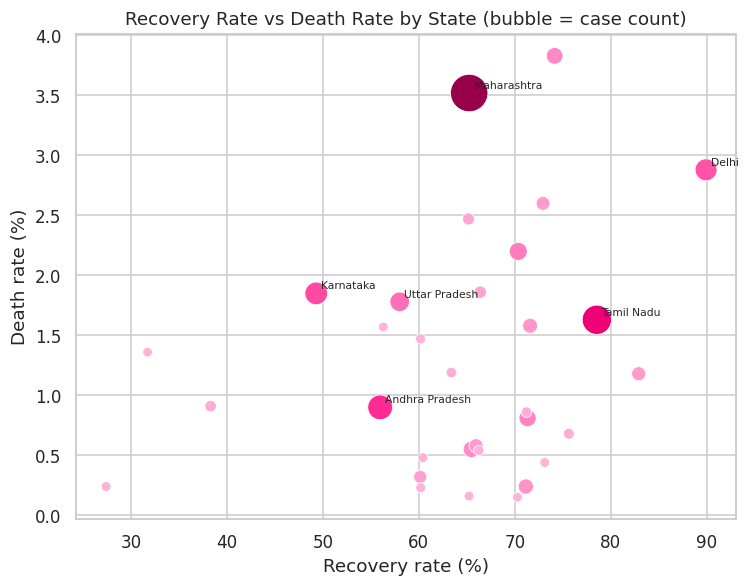

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
bright_pink = LinearSegmentedColormap.from_list("BrightPink", ["#FFB3D9", "#FF66B2", "#FF007F", "#CC0066", "#99004C"])

sizeable = latest[latest["confirmed"] >= 1000]

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.scatterplot(data=sizeable, x="recovery_rate", y="death_rate", size="confirmed",
                sizes=(40, 600), hue="confirmed", palette=bright_pink, legend=False, ax=ax)

for _, r in sizeable.nlargest(6, "confirmed").iterrows():
    ax.annotate(r["state"], (r["recovery_rate"], r["death_rate"]), fontsize=7,
                xytext=(3, 3), textcoords="offset points")

ax.set_title("Recovery Rate vs Death Rate by State (bubble = case count)")
ax.set_xlabel("Recovery rate (%)")
ax.set_ylabel("Death rate (%)")
plt.tight_layout()
plt.show()

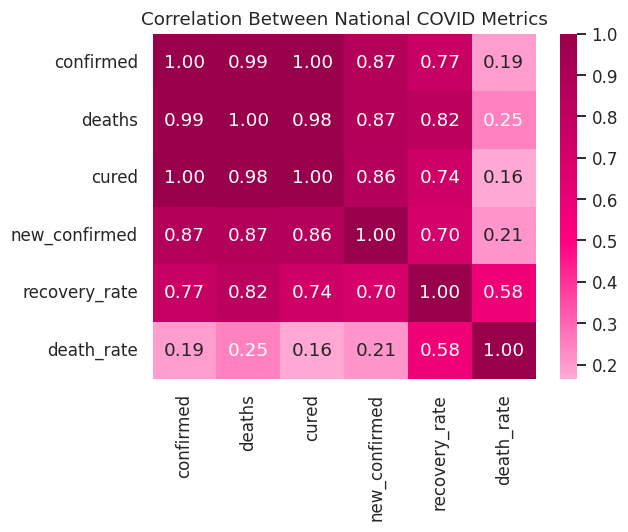

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
bright_diverging = LinearSegmentedColormap.from_list(
    "BrightCorr", ["#00F5D4", "#01BDE3", "#FFFFFF", "#FF007F", "#99004C"]
)

corr_cols = ["confirmed", "deaths", "cured", "new_confirmed", "recovery_rate", "death_rate"]
corr = national[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=bright_diverging, center=0, ax=ax)

ax.set_title("Correlation Between National COVID Metrics")
plt.tight_layout()
plt.show()


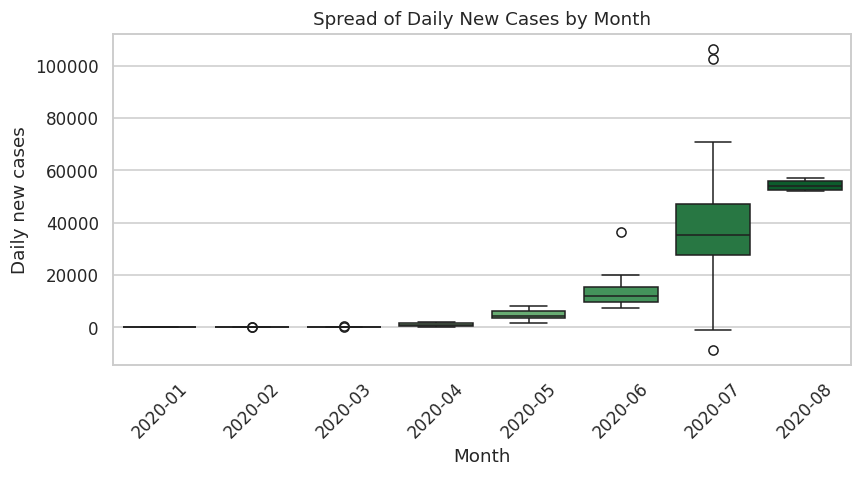

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

national["month"] = national["date"].dt.strftime("%Y-%m")
num_months = national["month"].nunique()

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=national, x="month", y="new_confirmed", hue="month",
            palette=sns.color_palette("Greens", num_months), legend=False, ax=ax)

ax.set_title("Spread of Daily New Cases by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Daily new cases")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

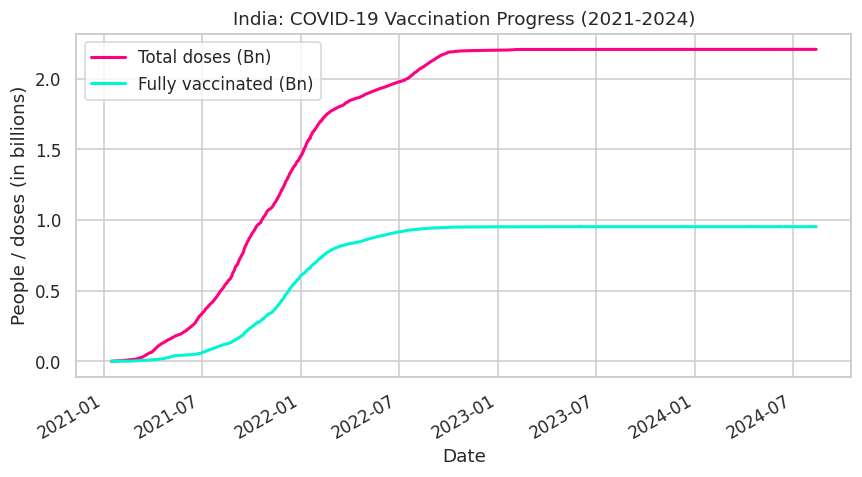

In [27]:
vax["date"] = pd.to_datetime(vax["date"])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(vax["date"], vax["total_vaccinations"] / 1e9, label="Total doses (Bn)", color="#FF007F", lw=2)
ax.plot(vax["date"], vax["people_fully_vaccinated"] / 1e9, label="Fully vaccinated (Bn)", color="#00F5D4", lw=2)
ax.set_title("India: COVID-19 Vaccination Progress (2021-2024)")
ax.set_xlabel("Date"); ax.set_ylabel("People / doses (in billions)")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

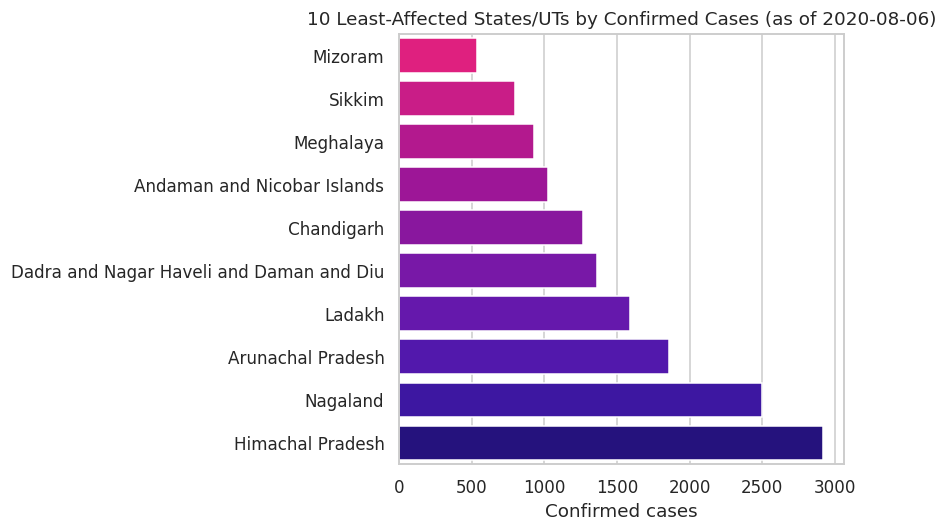

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
v_sunset = [
    "#FF007F", "#E6008E", "#CC009C", "#B300AB", "#9900B5",
    "#8000BF", "#6600C4", "#4D00C4", "#3300B8", "#1A008F"
]

bottom10 = latest[latest["confirmed"] > 0].nsmallest(10, "confirmed")

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=bottom10, y="state", x="confirmed", hue="state",
            palette=v_sunset, legend=False, ax=ax)

ax.set_title(f"10 Least-Affected States/UTs by Confirmed Cases (as of {latest_date.date()})")
ax.set_xlabel("Confirmed cases")
ax.set_ylabel("")

plt.tight_layout()
plt.show()